In [1]:

import jax 
import jax.numpy as jnp
#jax.config.update("jax_platform_name", "cpu")
from scoresbibm.src.utils.data_utils import load_model, query, get_summary_df

import matplotlib.pyplot as plt

In [2]:
t = jnp.linspace(0, 1, 10000)
def exp_power_scaling(t, scaling=100, max_steepness=1000, order=2):
    return jnp.exp(-t**order*scaling)*max_steepness


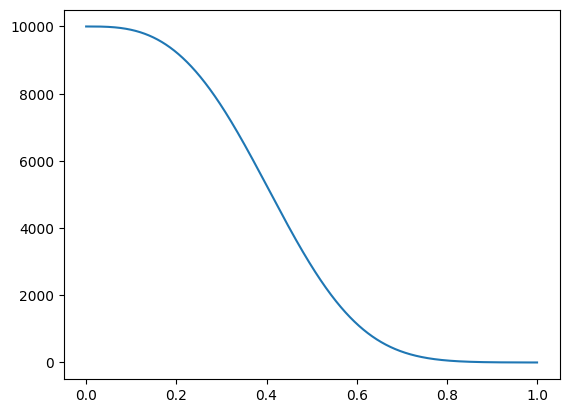

In [3]:
plt.plot(t, exp_power_scaling(t, scaling=10, max_steepness=10000, order=3))

In [78]:
# Numerical stability! (Sigmoid is numerically unstable for large values)
def log_step_fn(t,x,a,b, scaling_fn = exp_power_scaling):
    scale = scaling_fn(t)
    x = x.reshape(x.shape[0],-1)
    if a is None:
        x1 = 0.
    else:
        x1 = jax.nn.log_sigmoid(scale * (x - a))
    if b is None:
        x2 = 0.
    else:
        x2 = jax.nn.log_sigmoid(scale * (b- x))
    return jnp.sum(x1 + x2)

def log_linear_fn_approximation(t,x, a , scaling_fn = exp_power_scaling):
    scale = scaling_fn(t)
    x1 = jax.nn.log_sigmoid(scale * (jnp.sum(x * a, axis=1)))
    x2 = jax.nn.log_sigmoid(-scale * (jnp.sum(x * a, axis=1)))
    return x1 + x2

def log_conditional_fn(t,x, condition_mask, x_o, scaling_fn = exp_power_scaling):
    x = x.reshape(x.shape[0],-1)
    scale = scaling_fn(t)
    x_cond = x.at[...,condition_mask].set(x_o)
    x1 = scale * (-jnp.sum(jnp.abs(x - x_cond), axis=1))
    return x1
    

def smaller_equal_constraint_fn(t,x, constrating_fn, constrain_value, scaling_fn = exp_power_scaling):
    scale = scaling_fn(t)
    constraint = jax.nn.relu(scale * (constrating_fn(x) - constrain_value)).max(axis=-1)
    constraint = jax.nn.log_sigmoid(-constraint) 
    return constraint

# def get_constraint_score_fn(*constraint_fns, scaling_fn = exp_power_scaling):
#     def constraint_score_fn(t,x):
#         scale = scaling_fn(t)
#         constraints = [constraint_fn(x) for constraint_fn in constraint_fns]
        
#     return constraint_score_fn

def log_polytope_fn_approximation(t,x, A , scaling_fn = exp_power_scaling):
    return smaller_equal_constraint_fn(t,x, lambda x: x@A.T, 1., scaling_fn=scaling_fn)

step_fn_score = jax.grad(lambda *args: log_step_fn(*args).sum(), argnums=1)
linear_fn_score = jax.grad(lambda *args: log_linear_fn_approximation(*args).sum(), argnums=1)
log_conditional_fn_score = jax.grad(lambda *args: log_conditional_fn(*args).sum(), argnums=1)
log_polytope_fn_score = jax.grad(lambda *args: log_polytope_fn_approximation(*args).sum(), argnums=1)

In [79]:
def additve_score_modifier_fn(params, t, x, node_ids, condition_mask, edge_mask, base_score_fn, mod_score_fn):
    condition_mask = condition_mask.reshape(-1,len(node_ids), 1)
    score = base_score_fn(params,t, x, node_ids=node_ids, condition_mask=jnp.zeros_like(condition_mask), edge_mask=edge_mask)
    interval_score_est = step_fn_score(t,x,a,b).reshape(-1, len(node_ids), 1) * condition_mask.reshape(-1, len(node_ids), 1)

    return score + interval_score_est

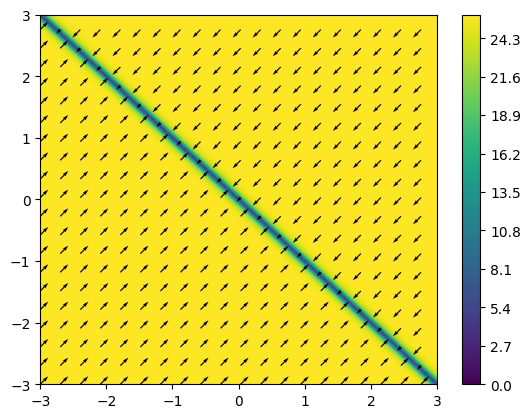

In [121]:
x = jnp.linspace(-3.,3.,100)
y = jnp.linspace(-3,3,100)
X,Y = jnp.meshgrid(x,y)
Z = jnp.stack([X,Y], axis=-1)
Z = Z.reshape(-1,2)
Z = linear_fn_score(0.2,Z, jnp.array([[1.,1.]]))
Z = Z.reshape(100,100, 2)
# 2d vector field
plt.contourf(X,Y,jnp.linalg.norm(Z, axis=-1), levels=200)
plt.colorbar()
plt.quiver(X[::5,::5],Y[::5,::5],Z[::5,::5,0],Z[::5,::5,1])

In [11]:
df = query("../results/benchmark", model_id=2)
df["task"].iloc[0]

'two_moons'

In [74]:
df = get_summary_df("../results/benchmark")
df

,method,task,num_simulations,seed,model_id,metric,value,time_train,time_eval,cfg
0,score_transformer,two_moons,1000,0,0,c2st,"[0.7907999753952026, 0.8011000156402588, 0.762...",405.382012,14.105814,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
1,score_transformer,two_moons,1000,0,1,c2st,"[0.6054499745368958, 0.6200000047683716, 0.600...",243.004187,6.925381,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
2,nspe,two_moons,1000,0,2,c2st,"[0.5515499711036682, 0.5672500133514404, 0.559...",28.093741,2.267969,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
3,nspe,two_moons,1000,0,3,c2st,"[0.5515000224113464, 0.5699999928474426, 0.559...",27.465629,2.258880,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
4,score_transformer,two_moons,1000,0,4,c2st,"[0.6014000177383423, 0.6244999766349792, 0.598...",335.166889,10.352422,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
5,score_transformer,two_moons,1000,0,5,c2st,"[0.5852000117301941, 0.6082500219345093, 0.594...",336.818093,10.470732,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
6,score_transformer,two_moons,1000,0,6,c2st,"[0.5613499879837036, 0.6060500144958496, 0.593...",224.148223,11.101278,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
7,score_transformer,two_moons,10000,0,7,c2st,"[0.5539000034332275, 0.5623000264167786, 0.557...",552.478095,12.229207,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
8,score_transformer,two_moons,10000,0,8,c2st,"[0.5506500005722046, 0.5593500137329102, 0.566...",725.672236,13.144215,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
9,score_transformer_joint,two_moons,10000,0,9,c2st,"[0.9100499749183655, 0.9362499713897705, 0.871...",552.936099,12.283738,"{'name': 'benchmark', 'seed': 0, 'save_model':..."


In [82]:
model = load_model("../results/benchmark/",47)

In [10]:
score_fn = model._init_score(node_id = model.node_id,condition_mask=jnp.zeros_like(condition_mask), edge_mask=None, meta_data=None)


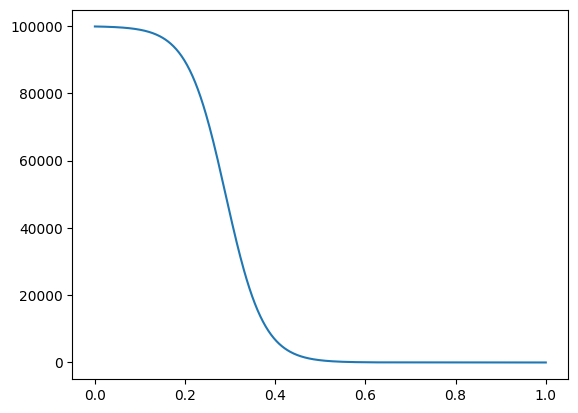

In [129]:
plt.plot(ts,1/(model.sde.marginal_stddev(ts, jnp.array([1.]))**2 + 0.00001))

In [83]:
condition_mask = jnp.array([False, False, True, True])
x_o = jnp.array([0.,0.])


In [84]:
x_t_mean = model.sde.marginal_mean(jnp.array([1.]))
x_t_std = model.sde.marginal_stddev(jnp.array([1.]))
x_T = jnp.squeeze(x_t_mean + x_t_std * jax.random.normal(jax.random.PRNGKey(2), shape=x_t_mean.shape))
ts = jnp.linspace(1., 1e-5, 500)
dt = ts[1] - ts[0]
x_observed = jnp.zeros_like(x_T)
x_observed = x_observed.at[condition_mask].set(x_o)

@jax.grad
def c(x):
    return -(condition_mask*(x - x_observed)**2).sum()

def s(t):
    std = model.sde.marginal_stddev(t, jnp.array([1.]))
    return (1/std**2) #*(condition_mask*(x - x_observed)**2).sum()


key = jax.random.PRNGKey(1)
for i,t in enumerate(ts):
    key, subkey = jax.random.split(key)
    score = score_fn(t, x_T)
    x_0_pred = (x_T + model.sde.marginal_stddev(t, jnp.array([1.]))**2 * score)/model.sde.marginal_mean(t, jnp.array([1.])) # Predict x0
    constraint_score = c(x_0_pred)
    score = score + s(t)*constraint_score
    drift_backward = model.sde.drift(t, x_T) - 0.5 * model.sde.diffusion(t, x_T)**2 * score
    diffusion_backward = model.sde.diffusion(t, x_T) 
    if (i % 10 == 0):
        print("x_t", x_T)
        print("x0_pred", x_0_pred)
    x_T = x_T + drift_backward * dt + diffusion_backward * jnp.sqrt(jnp.abs(dt)) * jax.random.normal(subkey, shape=x_T.shape)

x_t [  6.437 -13.426   2.291 -24.171]
x0_pred [-0.406 -0.743 -0.597  0.661]
x_t [  4.573   2.436  -0.669 -23.984]
x0_pred [ 0.171 -0.304 -0.252 -1.528]
x_t [  5.452 -12.587 -13.648 -15.671]
x0_pred [ 0.468  0.286 -0.033  0.209]
x_t [  0.688  -1.712  -9.389 -21.889]
x0_pred [ 0.082  0.269 -0.461 -0.196]
x_t [ -2.11   -0.28   -7.313 -16.588]
x0_pred [ 0.38  -0.285 -0.372 -1.654]
x_t [ -2.88    1.089  -7.509 -10.082]
x0_pred [ 0.238 -0.106 -0.15   0.091]
x_t [ -1.219  -2.923  -2.201 -10.34 ]
x0_pred [ 0.201 -0.204 -0.159 -0.293]
x_t [-0.434 -0.129  1.756 -7.243]
x0_pred [ 0.118 -0.12  -0.024 -0.104]
x_t [ 0.579  0.278  1.023 -6.036]
x0_pred [ 0.279 -0.169 -0.133 -0.291]
x_t [ 1.71  -0.896  1.699 -5.635]
x0_pred [ 0.468 -0.393 -0.003 -0.94 ]
x_t [ 0.653 -0.535  1.022 -4.757]
x0_pred [ 0.501 -0.417 -0.02  -0.463]
x_t [ 0.417 -0.537  0.295 -4.742]
x0_pred [ 0.613 -0.573 -0.027 -0.945]
x_t [ 0.387 -0.787 -1.077 -3.893]
x0_pred [ 0.54  -0.624 -0.064 -1.092]
x_t [-0.016 -0.627 -0.903 -2.345]
x0

In [108]:

def c(x,t):
    # Match observed values
    scale = s(t)
    return -jnp.sum(scale*(condition_mask*(x - x_observed)**2))


def c2(x,t):
    scale = s(t)
    c1 = jax.nn.log_sigmoid(scale * (x - 0.))
    c2 = jax.nn.log_sigmoid(scale * (0.1- x))
    return jnp.sum(condition_mask*(c1 + c2))

def s(t):
    t = jnp.atleast_1d(t)
    std = model.sde.marginal_stddev(t, jnp.array([1.]))
    return (1/std**2) 


def s2(t):
    t = jnp.atleast_1d(t)
    return jnp.exp(-t**2*5)*500


In [109]:
def generalized_guidance(model,key, condition_mask,x_o, constraint_fn, ts, resampling_steps=0):
    
    score_fn = model._init_score(node_id = model.node_id,condition_mask=jnp.zeros_like(condition_mask), edge_mask=None, meta_data=None)
    x_t_mean = model.sde.marginal_mean(jnp.array([1.]))
    x_t_std = model.sde.marginal_stddev(jnp.array([1.]))
    key, subkey = jax.random.split(key)
    x_T = jnp.squeeze(x_t_mean + x_t_std * jax.random.normal(subkey, shape=x_t_mean.shape))

    x_o = x_T.at[condition_mask].set(x_o)
    
    constraint_score_fn = jax.grad(constraint_fn, argnums=0)
    
    def scan_fn(carry, t0):
        key,t1, x1 = carry 
        dt = t0 - t1
        # Predict the unknown values at t0 given values from t1
        key, subkey = jax.random.split(key)
        score = score_fn(t1, x1)
        x_tweedy_estimator = (x1 + model.sde.marginal_stddev(t1, jnp.array([1.]))**2 * score)/model.sde.marginal_mean(t1, jnp.array([1.])) # Predict x0
        constraint_score = constraint_score_fn(x_tweedy_estimator, t1)
        score = score + constraint_score
        drift_backward = model.sde.drift(t1, x1) - model.sde.diffusion(t1, x1)**2 * score
        diffusion_backward = model.sde.diffusion(t1, x1) 
        x0 = x1 + drift_backward * dt + diffusion_backward * jnp.sqrt(jnp.abs(dt)) * jax.random.normal(subkey, shape=x1.shape)

        
        for _ in range(resampling_steps):
            # Forward sample from the SDE
            key, subkey = jax.random.split(key)
            x1 = x0 - model.sde.drift(t0, x0) * dt - model.sde.diffusion(t0, x0) * jnp.sqrt(jnp.abs(dt)) * jax.random.normal(subkey, shape=x1.shape)
            
            # Update again
            key, subkey = jax.random.split(key)
            score = score_fn(t1, x1)
            x_tweedy_estimator = (x1 + model.sde.marginal_stddev(t1, jnp.array([1.]))**2 * score)/model.sde.marginal_mean(t1, jnp.array([1.])) # Predict x0
            constraint_score = constraint_score_fn(x_tweedy_estimator,t1)
            score = score + constraint_score
            drift_backward = model.sde.drift(t1, x1) -  model.sde.diffusion(t1, x1)**2 * score
            diffusion_backward = model.sde.diffusion(t1, x1) 
            x0 = x1 + drift_backward * dt + diffusion_backward * jnp.sqrt(jnp.abs(dt)) * jax.random.normal(subkey, shape=x1.shape)

            
        return (key, t0, x0), x0
    
    
    carry = (key, ts[-1], x_T)
    _, x_T = jax.lax.scan(scan_fn, carry, ts[::-1][1:])
    return x_T

In [110]:
samples = generalized_guidance(model, key+5, condition_mask, x_o, c2, jnp.linspace(1e-5,1., 1000), resampling_steps=5)

In [111]:
@jax.vmap
def sample_fn(key):
    return generalized_guidance(model, key, condition_mask, x_o, c2, jnp.linspace(1e-5,1., 500), resampling_steps=10)[-1]

In [112]:
samples = sample_fn(jax.random.split(jax.random.PRNGKey(0), 1000))

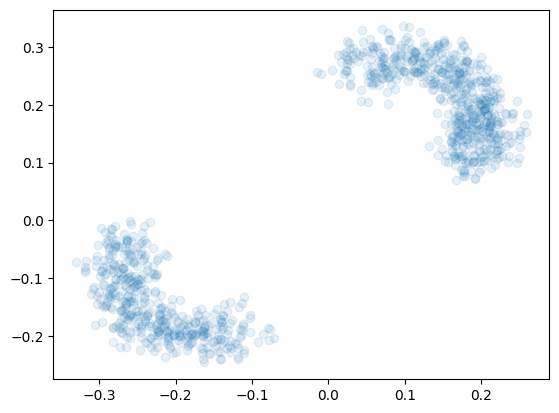

In [113]:
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)

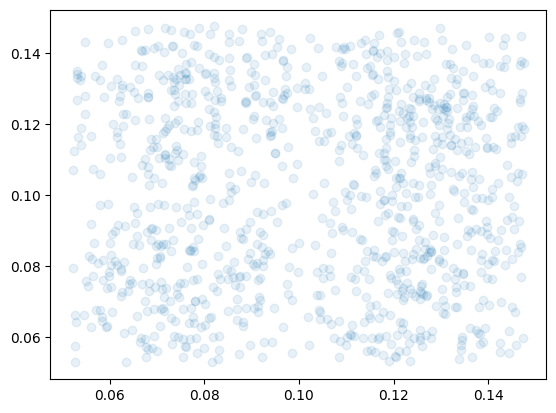

In [107]:
plt.scatter(samples[:,2], samples[:,3], alpha=0.1)

In [59]:
def repaint(model,key, condition_mask,x_o, num_steps=500, resampling_steps=10):
    
    ts = jnp.linspace(model.T_min, model.T_max, num_steps)
    score_fn = model._init_score(node_id = model.node_id,condition_mask=jnp.zeros_like(condition_mask), edge_mask=None, meta_data=None)
    x_t_mean = model.sde.marginal_mean(jnp.array([1.]))
    x_t_std = model.sde.marginal_stddev(jnp.array([1.]))
    key, subkey = jax.random.split(key)
    x_T = jnp.squeeze(x_t_mean + x_t_std * jax.random.normal(subkey, shape=x_t_mean.shape))

    x_o = x_T.at[condition_mask].set(x_o)
    
    def scan_fn(carry, t0):
        key,t1, x1 = carry 
        dt = t0 - t1
        #print(dt)
        key, subkey = jax.random.split(key)
        # Sample from the marginal distirbution at t0, given known values x_o
        x0_mean = model.sde.marginal_mean(t0, x_o)
        x0_std = model.sde.marginal_stddev(t0, x_o)
        x0_known = x0_mean + x0_std * jax.random.normal(subkey, shape=x1.shape)
        # Predict the unknown values at t0 given values from t1
        key, subkey = jax.random.split(key)
        score = score_fn(t1, x1)
        drift_backward = model.sde.drift(t1, x1) -  model.sde.diffusion(t1, x1)**2 * score
        diffusion_backward = model.sde.diffusion(t1, x1) 
        x0_unknown = x1 + drift_backward * dt + diffusion_backward * jnp.sqrt(jnp.abs(dt)) * jax.random.normal(subkey, shape=x1.shape)
        x0 = condition_mask * x0_known + (1 - condition_mask) * x0_unknown
        
        for _ in range(resampling_steps):
            # Forward sample from the SDE
            key, subkey = jax.random.split(key)
            x1 = x0 - model.sde.drift(t0, x0) * dt + model.sde.diffusion(t0, x0) * jnp.sqrt(jnp.abs(dt)) * jax.random.normal(subkey, shape=x1.shape)
            
            # Update again
            key, subkey = jax.random.split(key)
            # Sample from the marginal distirbution at t0, given known values x_o
            x0_mean = model.sde.marginal_mean(t0, x_o)
            x0_std = model.sde.marginal_stddev(t0, x_o)
            x0_known = x0_mean + x0_std * jax.random.normal(subkey, shape=x1.shape)
            # Predict the unknown values at t0 given values from t1
            key, subkey = jax.random.split(key)
            score = score_fn(t1, x1)
            drift_backward = model.sde.drift(t1, x1) - model.sde.diffusion(t1, x1)**2 * score
            diffusion_backward = model.sde.diffusion(t1, x1) 
            x0_unknown = x1 + drift_backward * dt + diffusion_backward * jnp.sqrt(jnp.abs(dt)) * jax.random.normal(subkey, shape=x1.shape)
            x0 = condition_mask * x0_known + (1 - condition_mask) * x0_unknown
            
        return (key, t0, x0), x0
    
    
    carry = (key, ts[-1], x_T)
    _, x_T = jax.lax.scan(scan_fn, carry, ts[::-1][1:])
    return x_T

In [71]:
#with jax.disable_jit():
@jax.vmap
def sample_fn(key):
    samples = repaint(model, key,condition_mask, x_o, jnp.linspace(1e-5, 1.,1000), resampling_steps=5)
    return samples[-1]

In [72]:
samples = sample_fn(jax.random.split(jax.random.PRNGKey(0), 1000))

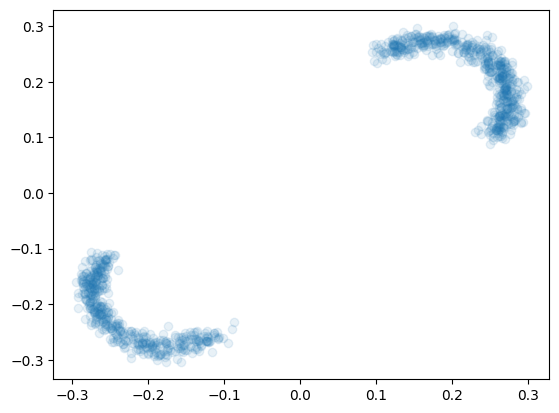

In [73]:
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)

In [131]:
samples

Array([[ 16.07 ,  -2.015, -13.069,  -4.428],
       [ 15.762,  -2.074,  18.678,   2.744],
       [ 10.252,   3.946,  12.63 ,  -5.121],
       ...,
       [  0.334,  -0.043,  -0.   ,   0.   ],
       [  0.334,  -0.043,   0.   ,  -0.   ],
       [  0.334,  -0.043,  -0.   ,   0.   ]], dtype=float32)

In [116]:
from probjax.utils.sdeint import register_method

In [117]:
x_o = jnp.array([0.,0.])
condition_mask = jnp.array([False, False, True, True])
constraint_mask = jnp.array([False, False, False, True])

In [118]:
#with jax.disable_jit():
better_samples = model.sample(1000, x_o=x_o, condition_mask=condition_mask, rng=jax.random.PRNGKey(0),sampling_method="sde",num_steps=1000)

In [13]:
#with jax.disable_jit():
samples = model.sample(100, x_o=x_o, condition_mask=condition_mask, rng=jax.random.PRNGKey(0),sampling_method="repaint",num_steps=1000, resampling_steps=1)

Original Traced<ShapedArray(float32[4])>with<DynamicJaxprTrace(level=3/0)>
Updated Traced<ShapedArray(float32[4])>with<DynamicJaxprTrace(level=3/0)>
Resampled Traced<ShapedArray(float32[4])>with<DynamicJaxprTrace(level=3/0)>
Reupdated Traced<ShapedArray(float32[4])>with<DynamicJaxprTrace(level=3/0)>


In [11]:
#with jax.disable_jit():
samples = model.sample(1000, x_o=x_o, condition_mask=condition_mask, rng=jax.random.PRNGKey(0),sampling_method="generalized_guidance",num_steps=1000, score_manipulator="interval", constraint_mask=constraint_mask, score_manipulator_kwargs={"a":-0.1, "b":0.})

(-1.0, 1.0)

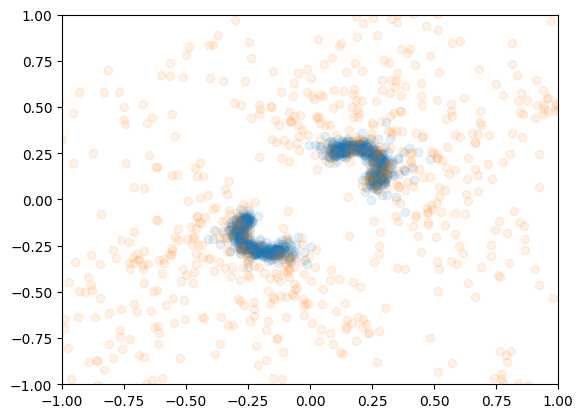

In [134]:
plt.scatter(better_samples[:,0], better_samples[:,1], alpha=0.1)
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.ylim(-1,1)
plt.xlim(-1,1)

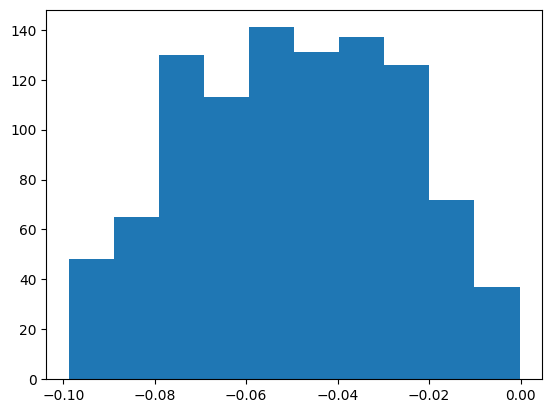

In [15]:
_ = plt.hist(samples[:,2:].flatten())

In [5]:
register_repaint_step_fn(model, condition_mask, x_o)

NameError: name 'register_repaint_step_fn' is not defined